In [1]:
import polars as pl
import pandas as pd



In [2]:
filepath = "tracking_results/DeepEcoHAB_20260501_211615_007DLC_DekrW18_the_future_of_EcohabNov22shuffle1_snapshot_best-260_el.h5"

In [3]:
tracking_df = pd.read_hdf(filepath)

out_df = tracking_df.copy()
scorer = out_df.columns.get_level_values("scorer")[0]

long_pdf = (
    tracking_df
    .stack(["scorer", "individuals", "bodyparts"])
    #.rename(["x","y"])
    .reset_index()
)
tracking_lf = pl.from_pandas(long_pdf).lazy().rename({'level_0':"frame"}).drop('scorer') #ograć rename wczytywaniem z hdf

/tmp/ipykernel_39975/1113783982.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(["scorer", "individuals", "bodyparts"])


In [ ]:
import numpy as np

jump_from_null_expr = (pl.col('x').is_null() != pl.col('x').shift().over('individuals').is_null() )

tracking_lf = tracking_lf.filter(
    pl.col('bodyparts') == "Dorsal2",#to decide, maybe centroid instead
).sort(
    ["individuals", "frame"]
).with_columns(
    sum(pl.col(c).diff().over('individuals').pow(2) for c in ['x','y']).sqrt().alias('jump_dist'),
    (pl.col("x").is_between(460,830) & pl.col("y").is_between(300,970)).fill_null(False).alias("center")
).with_columns(
    [pl.when(
        ((pl.col("likelihood") >= 0.7)  & (pl.col('center').not_()))#magic numbers 
    ).then(
        pl.col(c)
    ).otherwise(None).alias(c)
    for c in ["x", "y"]]
).with_columns(
    (((pl.col('jump_dist')>20)& ~(pl.col('jump_dist').is_null()))).fill_null(False).alias('jump')
    # *[pl.col(c).interpolate().over("individuals").alias(c)
    # for c in ["x", "y"]]
).sort(["frame"])
#.drop(pl.col("likelihood"))#.collect()

In [27]:
jump_events = (
    tracking_lf
    .filter(pl.col("jump"))
    .select(
        "frame",
        "individuals",
        "x",
        "y",
        "likelihood",
        "jump_dist",
        "center",
    )
    .sort(["frame", "individuals"])
)

jump_events.collect()

frame,individuals,x,y,likelihood,jump_dist,center
i64,str,f64,f64,f64,f64,bool
405,"""ind7""",1150.706665,393.442139,0.917873,21.685747,false
406,"""ind7""",1172.969482,383.563354,0.885464,24.356178,false
805,"""ind1""",992.58197,53.597733,0.804775,832.761816,false
806,"""ind1""",1162.796265,869.358337,0.95154,833.329629,false
822,"""ind1""",387.799652,138.212097,0.796468,1069.735807,false
…,…,…,…,…,…,…
107850,"""ind2""",407.829987,861.683472,0.949052,607.609276,false
107856,"""ind2""",996.616577,1066.371704,0.969252,47.659652,false
107857,"""ind2""",413.322449,866.301819,0.95768,616.652251,false


In [28]:
jump_frames = (
    tracking_lf
    .filter(pl.col("jump"))
    .group_by("frame")
    .agg(
        pl.col("individuals").sort().alias("jumping_mice"),
        pl.len().alias("n_jumping_mice"),
    )
    .sort("frame")
)

jump_frames.collect().to_pandas()

,frame,jumping_mice,n_jumping_mice
0,405,[ind7],1
1,406,[ind7],1
2,805,[ind1],1
3,806,[ind1],1
4,822,[ind1],1
...,...,...,...
3216,107850,[ind2],1
3217,107856,[ind2],1
3218,107857,[ind2],1
3219,107867,[ind2],1


In [30]:
for coord in ["x", "y", "likelihood"]:
    wide_coord = tracking_lf.collect().pivot(
        index="frame",
        on="individuals",
        values=coord,
    )

    for individual in wide_coord.columns:
        out_df[(scorer, individual, "Dorsal2", coord)] = wide_coord[(individual)].to_numpy()

out_df.to_hdf(
    "DeepEcoHAB_20260501_211615_007DLC_DekrW18_the_future_of_EcohabNov22shuffle1_snapshot_best-260_el.h5",
    key="df_with_missing",
    mode="w",
)

tracking_lf.collect().to_pandas()

,frame,individuals,bodyparts,x,y,likelihood,jump_dist,center,jump
0,0,ind1,Dorsal2,NaN,NaN,0.383084,NaN,False,False
1,0,ind2,Dorsal2,NaN,NaN,0.528054,NaN,False,False
2,0,ind3,Dorsal2,NaN,NaN,0.813487,NaN,False,False
3,0,ind4,Dorsal2,NaN,NaN,0.850423,NaN,False,False
4,0,ind5,Dorsal2,210.343430,308.119843,0.923215,NaN,False,False
...,...,...,...,...,...,...,...,...,...
763037,107999,ind4,Dorsal2,NaN,NaN,0.852806,NaN,False,False
763038,107999,ind5,Dorsal2,1108.964478,958.474060,0.914273,0.970226,False,False
763039,107999,ind6,Dorsal2,NaN,NaN,0.523328,NaN,False,False
763040,107999,ind7,Dorsal2,415.452484,136.453751,0.975447,0.281263,False,False


In [8]:
antenna_df = pl.scan_csv(
    "tracking_results/DeepEcoHAB_20260501_211615_antenna_data.csv", 
    has_header=False,
    separator=";",
    new_columns=['antenna', 'tag', 'timestamp', 'datetime'],
    infer_schema_length=1000
    ).with_columns(
        pl.col('timestamp').str.to_integer(base=16)
    )

video_index = 7 #to extract from filename suffix
frames_per_video = 108000

antenna_df = antenna_df.with_columns(
    (pl.col('antenna')==10).cum_sum().alias('frame')
).filter(
    pl.col('frame').is_between(frames_per_video*video_index, frames_per_video*(video_index+1)-1)
).with_columns(
    (pl.col('frame')-pl.col('frame').first()).alias('frame')
)

In [9]:
antenna_df.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,10,01000000,13881021,2026-05-02T04:16:25.187506,0
1,10,01000000,13881025,2026-05-02T04:16:25.234955,1
2,10,01000000,13881028,2026-05-02T04:16:25.267095,2
3,10,01000000,13881031,2026-05-02T04:16:25.299101,3
4,10,01000000,13881035,2026-05-02T04:16:25.330489,4
...,...,...,...,...,...
115307,10,01000000,14241014,2026-05-02T05:16:25.269040,107995
115308,10,01000000,14241017,2026-05-02T05:16:25.300795,107996
115309,10,01000000,14241021,2026-05-02T05:16:25.341808,107997
115310,10,01000000,14241024,2026-05-02T05:16:25.371307,107998


In [10]:
antenna_df.filter(pl.col('tag')=='02000000').collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,1,02000000,14053249,2026-05-02T04:45:07.549451,51667


In [11]:
animal_detections = antenna_df.filter(
    pl.col("antenna") != 10#remove magic string
)

In [12]:
animal_detections.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721
1,5,F02AE61A,13883427,2026-05-02T04:16:49.269069,722
2,5,F02AE61A,13883431,2026-05-02T04:16:49.300830,723
3,5,F02AE61A,13883435,2026-05-02T04:16:49.348346,724
4,5,F02AE61A,13883439,2026-05-02T04:16:49.380227,725
...,...,...,...,...,...
7307,1,F02AE61A,14235857,2026-05-02T05:15:33.706488,106448
7308,1,F02AE61A,14235861,2026-05-02T05:15:33.737894,106449
7309,1,F02AE61A,14235865,2026-05-02T05:15:33.785172,106450
7310,1,F02AE61A,14235869,2026-05-02T05:15:33.826882,106451


In [13]:
animal_detections = animal_detections.with_columns(
    (
        pl.struct(["antenna", "tag"]).ne(pl.struct(["antenna", "tag"]).shift())
        | pl.col("frame").diff().gt(5)
    )
    .cum_sum()
    .cast(pl.Int16)
    .alias("run_id")
    .fill_null(0)
)
animal_detections.collect().to_pandas()
#group by run id of antenna and tag, with columns under antenna - in the future take the actual timestamp instead of frame

,antenna,tag,timestamp,datetime,frame,run_id
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0
1,5,F02AE61A,13883427,2026-05-02T04:16:49.269069,722,0
2,5,F02AE61A,13883431,2026-05-02T04:16:49.300830,723,0
3,5,F02AE61A,13883435,2026-05-02T04:16:49.348346,724,0
4,5,F02AE61A,13883439,2026-05-02T04:16:49.380227,725,0
...,...,...,...,...,...,...
7307,1,F02AE61A,14235857,2026-05-02T05:15:33.706488,106448,1459
7308,1,F02AE61A,14235861,2026-05-02T05:15:33.737894,106449,1459
7309,1,F02AE61A,14235865,2026-05-02T05:15:33.785172,106450,1459
7310,1,F02AE61A,14235869,2026-05-02T05:15:33.826882,106451,1459


In [14]:
antenna_with_coords = animal_detections.join(
    tracking_lf,
    on = 'frame',
    how = 'left'
)

In [15]:
antenna_with_coords = antenna_with_coords.filter((pl.col('tag') != '02000000') & (pl.col('tag') != '02000060')) #maybe use sanitation for that

In [16]:
antenna_with_coords.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame,run_id,individuals,bodyparts,x,y,likelihood,jump_dist,center,jump
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind1,Dorsal2,1044.807983,744.289185,0.955294,2.610515,False,False
1,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind2,Dorsal2,NaN,NaN,0.537632,429.252125,True,True
2,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind3,Dorsal2,NaN,NaN,0.820318,0.146796,True,False
3,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind4,Dorsal2,NaN,NaN,0.716963,0.237002,True,False
4,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind5,Dorsal2,201.814240,310.670593,0.924400,0.277763,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51522,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind4,Dorsal2,NaN,NaN,0.822526,0.191830,True,False
51523,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind5,Dorsal2,1131.467163,946.468811,0.934604,0.188446,False,False
51524,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind6,Dorsal2,389.522766,170.759018,0.946226,2.433174,False,False
51525,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind7,Dorsal2,170.023682,366.717133,0.972335,3.207791,False,False


In [17]:
antenna_with_coords.group_by(
    ['run_id', 'antenna', 'tag', 'individuals']
).agg(
    pl.col("x").mean(),
    pl.col("y").mean(),
).collect().to_pandas()

,run_id,antenna,tag,individuals,x,y
0,293,7,EE1CEC1A,ind1,NaN,NaN
1,533,1,6D68A819,ind1,131.258621,904.627014
2,14,8,12F5FF19,ind2,933.463684,1120.067749
3,331,8,EE1CEC1A,ind7,968.344284,1119.013306
4,320,4,EE1CEC1A,ind4,1042.621313,729.692737
...,...,...,...,...,...,...
10502,557,5,EE1CEC1A,ind5,NaN,NaN
10503,299,7,EE1CEC1A,ind6,412.094910,123.596680
10504,608,4,0265E61A,ind8,1041.555786,435.133830
10505,494,4,EE1CEC1A,ind8,979.106018,1091.936597


In [18]:
tst = antenna_with_coords.group_by(
    ['antenna']
).agg(
    pl.col("x").mean(),
    pl.col("y").mean(),
).collect()

In [19]:
import numpy as np
img = np.zeros([1280, 1280])

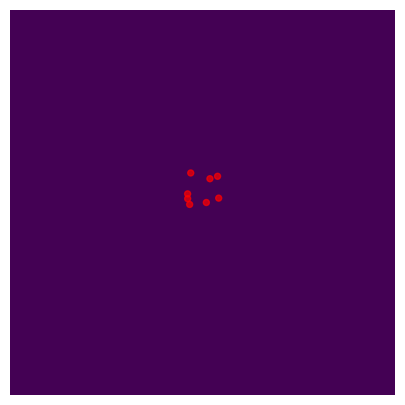

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(img)
ax.axis('off')

for x in tst.to_numpy():
    circle = Circle((x[1], x[2]), 10, color='red', fill=True, alpha=0.7)
    ax.add_patch(circle)

plt.show()

In [21]:
antenna_with_coords.filter(
    pl.col('antenna') == 7
).with_columns(
    pl.col('x').floordiv(10)
).collect().to_pandas()

,antenna,tag,timestamp,datetime,frame,run_id,individuals,bodyparts,x,y,likelihood,jump_dist,center,jump
0,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind1,Dorsal2,30.0,1126.216064,0.961690,5.354684,False,False
1,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind2,Dorsal2,93.0,1123.691895,0.927952,1.849342,False,False
2,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind3,Dorsal2,NaN,NaN,0.814230,0.725023,True,False
3,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind4,Dorsal2,NaN,NaN,0.533138,1.772167,False,False
4,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind5,Dorsal2,27.0,316.185333,0.888903,5.584064,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5282,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind4,Dorsal2,NaN,NaN,0.840509,0.060848,True,False
5283,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind5,Dorsal2,112.0,955.274536,0.893379,0.504621,False,False
5284,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind6,Dorsal2,46.0,245.456696,1.000000,1.187812,False,False
5285,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind7,Dorsal2,40.0,1096.478394,1.000000,0.595403,False,False


In [22]:
import polars as pl
data = [[510,250], [810,250], [1045,780], [1045,780], [810,1010], [510,1010], [270, 780], [270,480]]
antenna_locations = pl.DataFrame({"x":[510,810, 1045,1045,810,510,270,270], "y":[250,250,480,780,1010,1010,780,480]})
antenna_locations

x,y
i64,i64
510,250
810,250
1045,480
1045,780
810,1010
510,1010
270,780
270,480


In [23]:
antenna_with_coords_t = antenna_with_coords.select(['antenna', 'frame', 'tag', 'individuals', 'run_id', 'x', 'y'])

In [24]:
for i, d in enumerate(data):
    antenna_with_coords_t = antenna_with_coords_t.with_columns(
        (np.linalg.norm(np.array([pl.col("x"), pl.col("y")])- np.array([d[0], d[1]]))).alias(f"dist{i}")
    )

In [25]:
antenna_with_coords_t.filter(
    pl.col("dist1") < 50
).collect().to_pandas()

,antenna,frame,tag,individuals,run_id,x,y,dist0,dist1,dist2,dist3,dist4,dist5,dist6,dist7
0,5,2743,EE1CEC1A,ind7,25,853.419800,254.785522,343.453141,43.682722,559.064594,559.064594,756.461622,829.630078,785.002491,625.380063
1,5,2744,EE1CEC1A,ind7,25,840.948547,250.027649,330.948549,30.948560,567.897604,567.897604,760.602253,828.905854,779.007661,615.523782
2,5,2746,EE1CEC1A,ind7,25,809.742310,248.638504,299.745402,1.385668,581.112055,581.112055,761.361540,818.240050,757.407948,587.239221
3,5,2747,EE1CEC1A,ind7,25,799.988281,250.335114,289.988475,10.017326,583.588583,583.588583,759.730856,813.132181,749.287975,577.610196
4,5,2748,EE1CEC1A,ind7,25,788.093384,248.571091,278.097055,21.953169,590.269172,590.269172,761.743975,810.623164,742.184236,567.432899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,7,101786,3AFE9F1A,ind8,1394,851.070740,247.586502,341.079279,41.141593,566.632765,566.632765,763.518924,835.226671,788.103634,625.826844
376,7,101787,3AFE9F1A,ind8,1394,851.052612,247.347046,341.062930,41.138244,566.863968,566.863968,763.757059,835.437857,788.252059,625.898982
377,7,102741,F02AE61A,ind1,1409,853.283508,246.949188,343.297065,43.390892,566.478933,566.478933,764.277439,836.713875,790.166324,628.118088
378,7,102743,F02AE61A,ind1,1409,855.222168,245.810349,345.247590,45.415830,566.898765,566.898765,765.526530,838.548847,792.365805,630.341002
